# Model Comparison — v0 (Frozen Backbone) vs v1 (Fine-tuned Top Layers)

This notebook compares all trained model variants:
- **v0** — Frozen backbone, only linear head trained
- **v1a** — Unfreeze last 1 block (features[8] + classifier)
- **v1b** — Unfreeze last 2 blocks (features[7:] + classifier)
- **v1c** — Unfreeze last 3 blocks (features[6:] + classifier)

Metrics compared:
1. Test Accuracy & F1 (weighted, macro)
2. Per-class Precision / Recall / F1
3. Confusion Matrices (side-by-side)
4. Training Curves (loss, accuracy, F1)
5. Confidence Distribution Analysis
6. Error Analysis

In [1]:
import torch
import torch.nn as nn
import numpy as np
import json
import os
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, cohen_kappa_score,
    balanced_accuracy_score,
)
import pandas as pd

from utils_2_dataloader import (
    create_dataloaders, CLASS_NAMES, IDX_TO_CLASS_NAME,
)

print(f"PyTorch: {torch.__version__}")

/Users/nadiaroschina/Library/Mobile Documents/com~apple~CloudDocs/masters_icloud/PROJECT/teeth_classes_classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0


In [2]:
# Device
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

NUM_CLASSES = len(CLASS_NAMES)
print(f"Device: {DEVICE}")
print(f"Classes: {CLASS_NAMES}")

Device: mps
Classes: ['incisor', 'canine', 'premolar', 'molar']


## 1. Load / Evaluate All Models

We re-evaluate each model on the test set to collect predictions and probabilities.

In [3]:
print("Loading DataLoaders...")
train_loader, val_loader, test_loader = create_dataloaders(
    batch_size=32, num_workers=4,
)

Loading DataLoaders...
Всего валидных сэмплов: 3584
  incisor: 520 (14.5%)
  canine: 254 (7.1%)
  premolar: 1140 (31.8%)
  molar: 1670 (46.6%)
Разбивка -> Train: 2508, Val: 538, Test: 538


/Users/nadiaroschina/Library/Mobile Documents/com~apple~CloudDocs/masters_icloud/PROJECT/teeth_classes_classification/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [4]:
def build_model_v0(num_classes, device):
    """Recreate v0 model architecture (frozen backbone, linear head)."""
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier[1].parameters():
        param.requires_grad = True
    return model.to(device)


def build_model_v1(num_classes, unfreeze_from, device):
    """Recreate v1 model architecture (partial unfreeze)."""
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    for param in model.parameters():
        param.requires_grad = False
    for i in range(unfreeze_from, len(model.features)):
        for param in model.features[i].parameters():
            param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
    return model.to(device)

In [5]:
@torch.no_grad()
def evaluate_model(model, loader, device):
    """
    Evaluate model on a DataLoader.
    Returns dict with y_true, y_pred, probabilities, and per-sample loss.
    """
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="none")
    all_preds, all_labels, all_probs, all_losses = [], [], [], []

    for images, labels in tqdm(loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        losses = criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_losses.extend(losses.cpu().numpy())

    return {
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_preds),
        "probs": np.array(all_probs),
        "losses": np.array(all_losses),
    }

In [6]:
EXPERIMENTS = {
    "v0_frozen": {
        "checkpoint": "best_baseline_v0.pth",
        "build_fn": lambda: build_model_v0(NUM_CLASSES, DEVICE),
        "results_json": "results_v0_frozen.json",
        "label": "v0 (frozen backbone)",
        "color": "#1f77b4",
    },
    "v1a_unfreeze1": {
        "checkpoint": "best_v1a_unfreeze1.pth",
        "build_fn": lambda: build_model_v1(NUM_CLASSES, 8, DEVICE),
        "results_json": "results_v1a_unfreeze1.json",
        "label": "v1a (unfreeze 1 block)",
        "color": "#ff7f0e",
    },
    "v1b_unfreeze2": {
        "checkpoint": "best_v1b_unfreeze2.pth",
        "build_fn": lambda: build_model_v1(NUM_CLASSES, 7, DEVICE),
        "results_json": "results_v1b_unfreeze2.json",
        "label": "v1b (unfreeze 2 blocks)",
        "color": "#2ca02c",
    },
    "v1c_unfreeze3": {
        "checkpoint": "best_v1c_unfreeze3.pth",
        "build_fn": lambda: build_model_v1(NUM_CLASSES, 6, DEVICE),
        "results_json": "results_v1c_unfreeze3.json",
        "label": "v1c (unfreeze 3 blocks)",
        "color": "#d62728",
    },
}

eval_results = {}
for name, cfg in EXPERIMENTS.items():
    ckpt = cfg["checkpoint"]
    if not os.path.exists(ckpt):
        print(f'WARNING: Checkpoint "{ckpt}" not found, skipping {name}')
        continue

    print(f"\n--- Evaluating {name} ---")
    model = cfg["build_fn"]()
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    result = evaluate_model(model, test_loader, DEVICE)
    result["label"] = cfg["label"]
    result["color"] = cfg["color"]

    # Load training history from JSON if available
    json_path = cfg["results_json"]
    if os.path.exists(json_path):
        with open(json_path) as f:
            saved = json.load(f)
        result["history"] = saved.get("history", None)
    else:
        result["history"] = None

    eval_results[name] = result
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nSuccessfully evaluated {len(eval_results)} models.")


--- Evaluating v0_frozen ---


Evaluating: 100%|██████████| 17/17 [00:30<00:00,  1.80s/it]



--- Evaluating v1a_unfreeze1 ---


Evaluating: 100%|██████████| 17/17 [00:24<00:00,  1.47s/it]



--- Evaluating v1b_unfreeze2 ---


Evaluating: 100%|██████████| 17/17 [00:25<00:00,  1.48s/it]



--- Evaluating v1c_unfreeze3 ---


Evaluating: 100%|██████████| 17/17 [00:24<00:00,  1.46s/it]



Successfully evaluated 4 models.


## 2. Summary Metrics Table

In [7]:
rows = []
for name, r in eval_results.items():
    y_true, y_pred = r["y_true"], r["y_pred"]
    rows.append({
        "Model": r["label"],
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_true, y_pred),
        "F1 (weighted)": f1_score(y_true, y_pred, average="weighted"),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
        "Precision (wt)": precision_score(y_true, y_pred, average="weighted"),
        "Recall (wt)": recall_score(y_true, y_pred, average="weighted"),
        "Cohen Kappa": cohen_kappa_score(y_true, y_pred),
        "Mean Loss": r["losses"].mean(),
    })

df_summary = pd.DataFrame(rows).set_index("Model")

print("=" * 80)
print("SUMMARY METRICS (Test Set)")
print("=" * 80)
display(
    df_summary.style
    .highlight_max(
        subset=["Accuracy", "Balanced Acc", "F1 (weighted)", "F1 (macro)",
                "Precision (wt)", "Recall (wt)", "Cohen Kappa"],
        color="lightgreen"
    )
    .highlight_min(subset=["Mean Loss"], color="lightgreen")
    .format("{:.4f}")
)

SUMMARY METRICS (Test Set)


,Accuracy,Balanced Acc,F1 (weighted),F1 (macro),Precision (wt),Recall (wt),Cohen Kappa,Mean Loss
Model,,,,,,,,
v0 (frozen backbone),0.8253,0.7933,0.8235,0.7879,0.8255,0.8253,0.7314,0.5104
v1a (unfreeze 1 block),0.8922,0.8508,0.8913,0.8655,0.8915,0.8922,0.8341,0.3061
v1b (unfreeze 2 blocks),0.9182,0.8779,0.9193,0.8813,0.9226,0.9182,0.8758,0.2053
v1c (unfreeze 3 blocks),0.9498,0.9195,0.9493,0.9291,0.9495,0.9498,0.9231,0.1751


## 3. Per-Class Metrics

In [8]:
for name, r in eval_results.items():
    print(f"\n{'=' * 60}")
    print(f'  {r["label"]}')
    print(f"{'=' * 60}")
    print(classification_report(
        r["y_true"], r["y_pred"],
        target_names=CLASS_NAMES, digits=4
    ))


  v0 (frozen backbone)
              precision    recall  f1-score   support

     incisor     0.7042    0.6410    0.6711        78
      canine     0.7273    0.8421    0.7805        38
    premolar     0.8693    0.7778    0.8210       171
       molar     0.8481    0.9124    0.8791       251

    accuracy                         0.8253       538
   macro avg     0.7872    0.7933    0.7879       538
weighted avg     0.8255    0.8253    0.8235       538


  v1a (unfreeze 1 block)
              precision    recall  f1-score   support

     incisor     0.8219    0.7692    0.7947        78
      canine     0.9091    0.7895    0.8451        38
    premolar     0.8864    0.9123    0.8991       171
       molar     0.9141    0.9323    0.9231       251

    accuracy                         0.8922       538
   macro avg     0.8829    0.8508    0.8655       538
weighted avg     0.8915    0.8922    0.8913       538


  v1b (unfreeze 2 blocks)
              precision    recall  f1-score   support

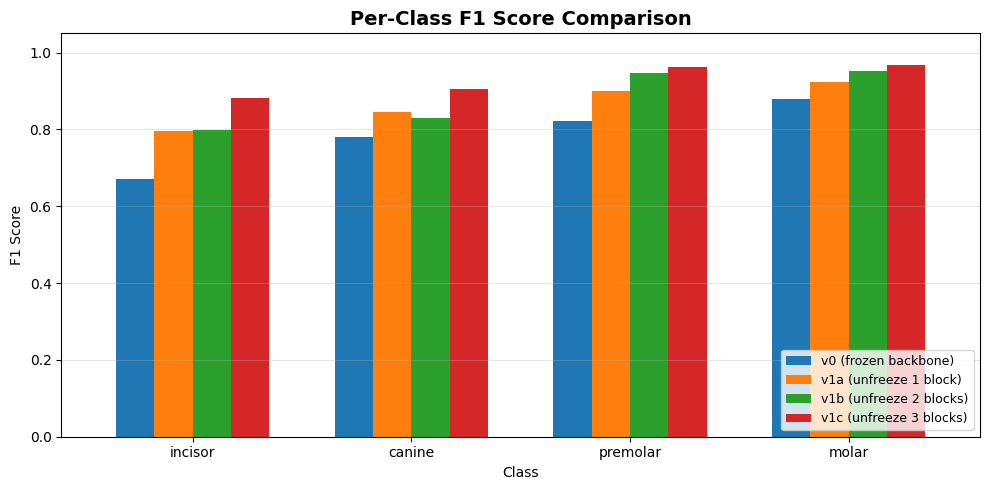

In [9]:
# Per-class F1 comparison bar chart
per_class_f1 = {}
for name, r in eval_results.items():
    f1s = f1_score(r["y_true"], r["y_pred"], average=None)
    per_class_f1[r["label"]] = f1s

df_f1 = pd.DataFrame(per_class_f1, index=CLASS_NAMES)

ax = df_f1.plot(
    kind="bar", figsize=(10, 5), width=0.7,
    color=[eval_results[n]["color"] for n in eval_results],
)
ax.set_title("Per-Class F1 Score Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("F1 Score")
ax.set_xlabel("Class")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("comparison_per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Confusion Matrices (Side-by-Side)

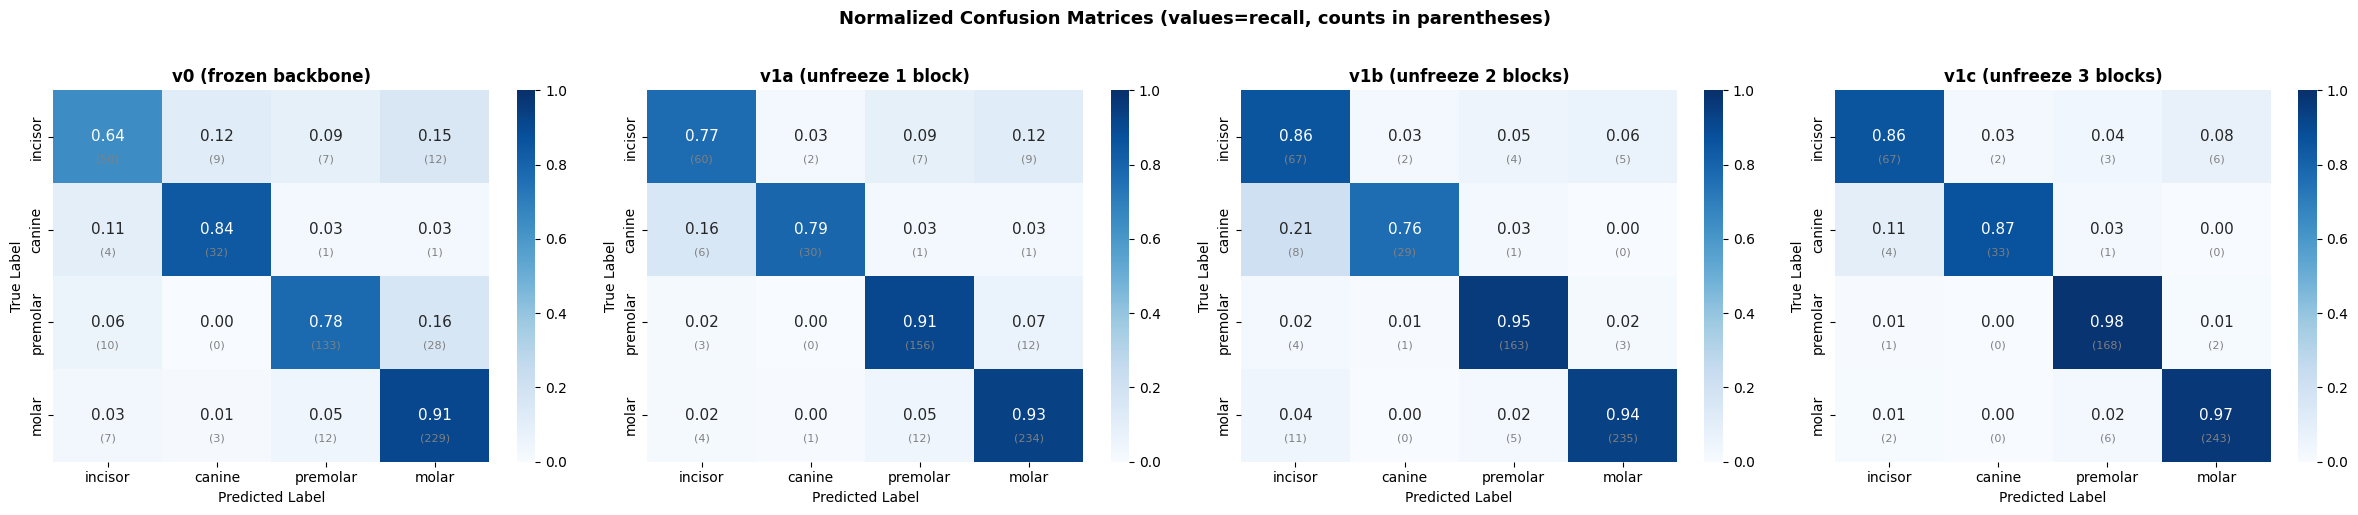

In [10]:
n_models = len(eval_results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, eval_results.items()):
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, vmin=0, vmax=1, annot_kws={"size": 11},
    )
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j + 0.5, i + 0.75, f"({cm[i, j]})",
                ha="center", va="center", fontsize=8, color="gray",
            )
    ax.set_title(r["label"], fontsize=12, fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle(
    "Normalized Confusion Matrices (values=recall, counts in parentheses)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("comparison_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Training Curves Comparison

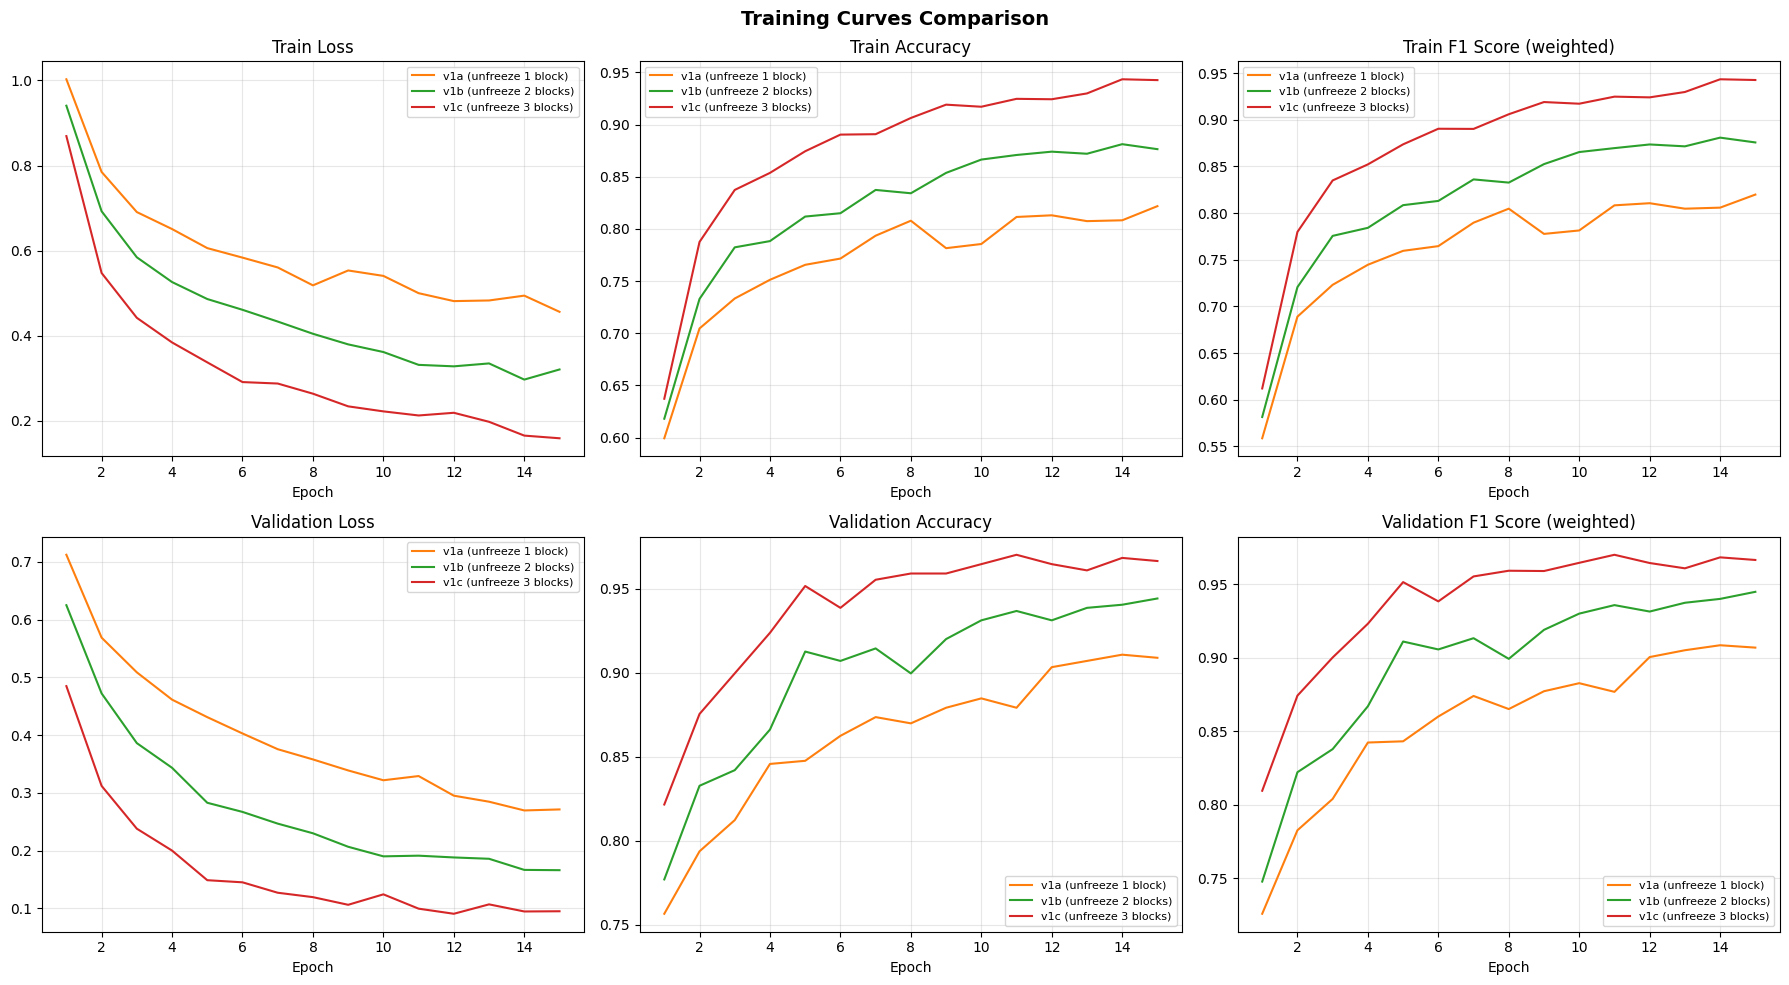

In [11]:
models_with_history = {
    name: r for name, r in eval_results.items()
    if r.get("history") is not None
}

if models_with_history:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    metrics = [
        ("train_loss", "val_loss", "Loss"),
        ("train_acc", "val_acc", "Accuracy"),
        ("train_f1", "val_f1", "F1 Score (weighted)"),
    ]
    for col, (train_key, val_key, title) in enumerate(metrics):
        ax_train = axes[0, col]
        ax_val = axes[1, col]
        for name, r in models_with_history.items():
            h = r["history"]
            epochs = range(1, len(h[train_key]) + 1)
            ax_train.plot(epochs, h[train_key], label=r["label"], color=r["color"])
            ax_val.plot(epochs, h[val_key], label=r["label"], color=r["color"])
        ax_train.set_title(f"Train {title}", fontsize=12)
        ax_train.legend(fontsize=8)
        ax_train.grid(True, alpha=0.3)
        ax_train.set_xlabel("Epoch")
        ax_val.set_title(f"Validation {title}", fontsize=12)
        ax_val.legend(fontsize=8)
        ax_val.grid(True, alpha=0.3)
        ax_val.set_xlabel("Epoch")
    plt.suptitle("Training Curves Comparison", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("comparison_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No training history available for any model.")

## 6. Confidence Distribution Analysis

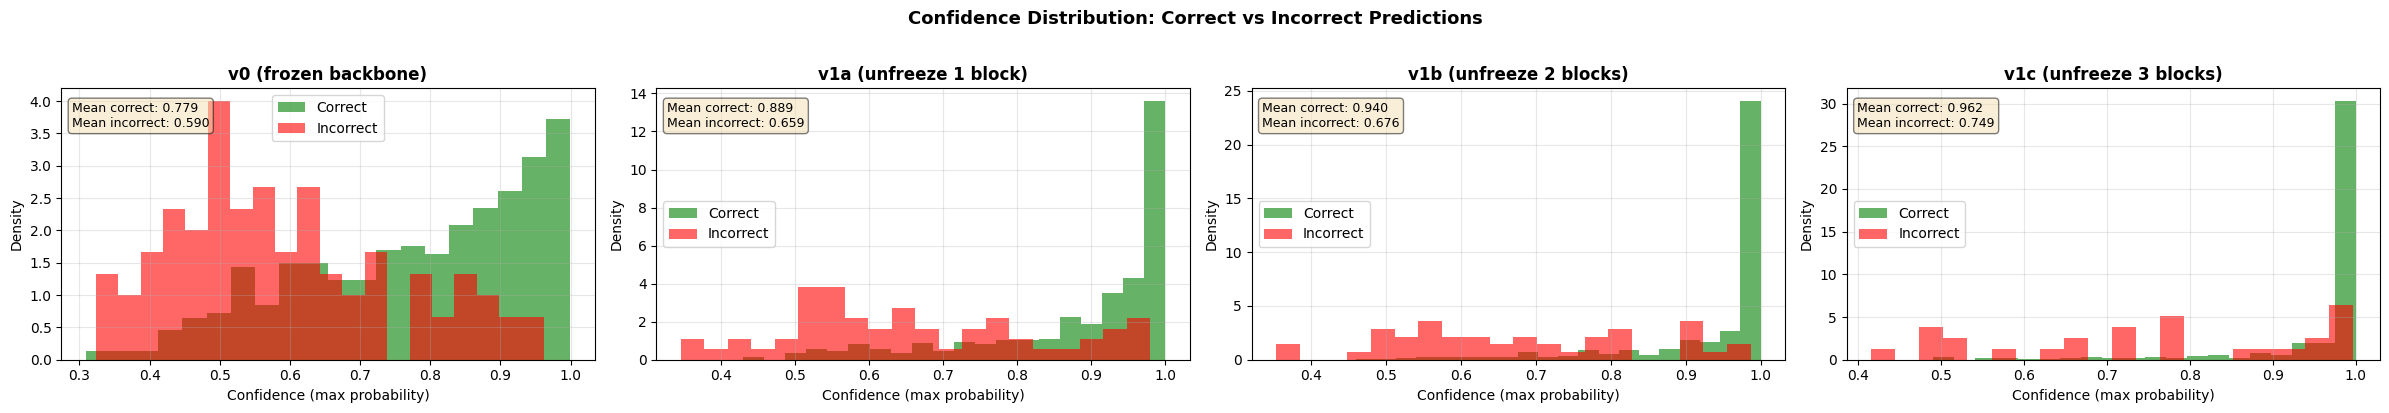

In [12]:
n = len(eval_results)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
if n == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, eval_results.items()):
    probs = r["probs"]
    y_true = r["y_true"]
    y_pred = r["y_pred"]
    confidences = probs.max(axis=1)
    correct_mask = (y_true == y_pred)

    ax.hist(confidences[correct_mask], bins=20, alpha=0.6,
            label="Correct", color="green", density=True)
    ax.hist(confidences[~correct_mask], bins=20, alpha=0.6,
            label="Incorrect", color="red", density=True)
    ax.set_title(r["label"], fontsize=12, fontweight="bold")
    ax.set_xlabel("Confidence (max probability)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

    mean_c = confidences[correct_mask].mean() if correct_mask.sum() > 0 else 0
    mean_i = confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0
    info = f"Mean correct: {mean_c:.3f}\nMean incorrect: {mean_i:.3f}"
    ax.text(0.02, 0.95, info,
            transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("Confidence Distribution: Correct vs Incorrect Predictions",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("comparison_confidence_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Error Analysis — Most Confused Class Pairs

In [13]:
for name, r in eval_results.items():
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    np.fill_diagonal(cm, 0)
    pairs = []
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            if cm[i, j] > 0:
                pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j]))
    pairs.sort(key=lambda x: x[2], reverse=True)

    print(f'\n{r["label"]} -- Top Confused Pairs:')
    print(f'  {"True":<12} {"Predicted":<12} {"Count":>6}')
    print(f'  {"-" * 32}')
    for true_cls, pred_cls, count in pairs[:5]:
        print(f"  {true_cls:<12} {pred_cls:<12} {count:>6}")


v0 (frozen backbone) -- Top Confused Pairs:
  True         Predicted     Count
  --------------------------------
  premolar     molar            28
  incisor      molar            12
  molar        premolar         12
  premolar     incisor          10
  incisor      canine            9

v1a (unfreeze 1 block) -- Top Confused Pairs:
  True         Predicted     Count
  --------------------------------
  premolar     molar            12
  molar        premolar         12
  incisor      molar             9
  incisor      premolar          7
  canine       incisor           6

v1b (unfreeze 2 blocks) -- Top Confused Pairs:
  True         Predicted     Count
  --------------------------------
  molar        incisor          11
  canine       incisor           8
  incisor      molar             5
  molar        premolar          5
  incisor      premolar          4

v1c (unfreeze 3 blocks) -- Top Confused Pairs:
  True         Predicted     Count
  --------------------------------
  incis

## 8. Overall Bar Chart Comparison

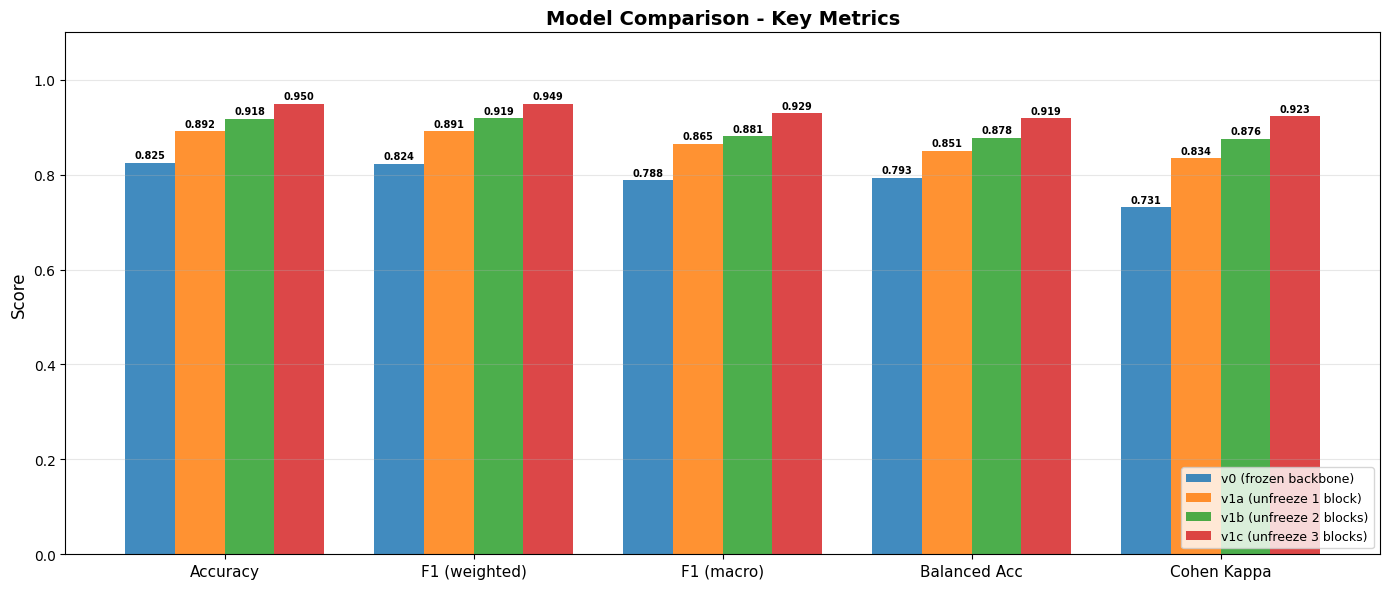

All comparison plots saved.


In [14]:
metric_names = ["Accuracy", "F1 (weighted)", "F1 (macro)", "Balanced Acc", "Cohen Kappa"]
metric_values = {m: [] for m in metric_names}
model_labels = []
model_colors = []

for name, r in eval_results.items():
    y_true, y_pred = r["y_true"], r["y_pred"]
    model_labels.append(r["label"])
    model_colors.append(r["color"])
    metric_values["Accuracy"].append(accuracy_score(y_true, y_pred))
    metric_values["F1 (weighted)"].append(f1_score(y_true, y_pred, average="weighted"))
    metric_values["F1 (macro)"].append(f1_score(y_true, y_pred, average="macro"))
    metric_values["Balanced Acc"].append(balanced_accuracy_score(y_true, y_pred))
    metric_values["Cohen Kappa"].append(cohen_kappa_score(y_true, y_pred))

x = np.arange(len(metric_names))
width = 0.8 / len(model_labels)

fig, ax = plt.subplots(figsize=(14, 6))
for i, (label, color) in enumerate(zip(model_labels, model_colors)):
    values = [metric_values[m][i] for m in metric_names]
    offset = i * width - 0.4 + width / 2
    bars = ax.bar(x + offset, values, width, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison - Key Metrics", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("All comparison plots saved.")

## 9. Final Summary

In [15]:
print("\n" + "=" * 80)
print("FINAL RANKING (by Test F1 weighted)")
print("=" * 80)

ranking = []
for name, r in eval_results.items():
    f1_w = f1_score(r["y_true"], r["y_pred"], average="weighted")
    ranking.append((r["label"], f1_w))

ranking.sort(key=lambda x: x[1], reverse=True)
for i, (label, f1_w) in enumerate(ranking, 1):
    marker = " <-- BEST" if i == 1 else ""
    print(f"  {i}. {label:<30} F1={f1_w:.4f}{marker}")


FINAL RANKING (by Test F1 weighted)
  1. v1c (unfreeze 3 blocks)        F1=0.9493 <-- BEST
  2. v1b (unfreeze 2 blocks)        F1=0.9193
  3. v1a (unfreeze 1 block)         F1=0.8913
  4. v0 (frozen backbone)           F1=0.8235
